In [5]:
# temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

#istatistik kütüphaneleri
from scipy import stats
import warnings

In [6]:
df = pd.read_csv('/content/sample_data/supermarket.csv')

In [7]:
print('supermarket verisi')
print(f'boyut:{df.shape}')
print(f'Boyut : {df.shape[0]} satır, {df.shape[1]} sütun')
print(f'kolonlar:{df.columns}')


supermarket verisi
boyut:(9800, 18)
Boyut : 9800 satır, 18 sütun
kolonlar:Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [9]:
# son 5 satırı bastırıyor
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [10]:
#rastgele beş satır
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
497,498,CA-2017-126158,25/07/2017,31/07/2017,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Costa Mesa,California,92627.0,West,FUR-FU-10004864,Furniture,Furnishings,"Howard Miller 14-1/2"" Diameter Chrome Round Wa...",255.760
8831,8832,CA-2016-145324,15/11/2016,19/11/2016,Standard Class,DH-13675,Duane Huffman,Home Office,United States,Harrisonburg,Virginia,22801.0,South,FUR-FU-10002759,Furniture,Furnishings,12-1/2 Diameter Round Wall Clock,39.960
6310,6311,CA-2017-163328,04/11/2017,06/11/2017,Second Class,TP-21565,Tracy Poddar,Corporate,United States,Eugene,Oregon,97405.0,West,OFF-PA-10000176,Office Supplies,Paper,Xerox 1887,15.176
5882,5883,CA-2017-133935,18/09/2017,22/09/2017,Standard Class,JW-15220,Jane Waco,Corporate,United States,San Diego,California,92105.0,West,FUR-CH-10002880,Furniture,Chairs,"Global High-Back Leather Tilter, Burgundy",885.528
4679,4680,CA-2015-114510,14/03/2015,19/03/2015,Standard Class,JF-15295,Jason Fortune-,Consumer,United States,Logan,Utah,84321.0,West,OFF-ST-10003221,Office Supplies,Storage,Staple magnet,21.360


In [11]:
print('Veri tipleri')
print('='*40)

df_type = pd.DataFrame({
    'sutun' : df.columns,
    'veri tipi' : df.dtypes,
    'null sayısı' : df.isnull().sum(),
    'null oranı' : df.isnull().sum()/df.shape[0],
    'unique sayısı' : df.nunique()
})

print(df_type.to_string(index=False))




Veri tipleri
        sutun veri tipi  null sayısı  null oranı  unique sayısı
       Row ID     int64            0    0.000000           9800
     Order ID    object            0    0.000000           4922
   Order Date    object            0    0.000000           1230
    Ship Date    object            0    0.000000           1326
    Ship Mode    object            0    0.000000              4
  Customer ID    object            0    0.000000            793
Customer Name    object            0    0.000000            793
      Segment    object            0    0.000000              3
      Country    object            0    0.000000              1
         City    object            0    0.000000            529
        State    object            0    0.000000             49
  Postal Code   float64           11    0.001122            626
       Region    object            0    0.000000              4
   Product ID    object            0    0.000000           1861
     Category    object    

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [13]:
#  Sayısal değişkenlerie ilgili temel istatistikler
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9800.0,4900.500000,2829.160653,1.000,2450.750,4900.50,7350.250,9800.00
Postal Code,9789.0,55273.322403,32041.223413,1040.000,23223.000,58103.00,90008.000,99301.00
Sales,9800.0,230.769059,626.651875,0.444,17.248,54.49,210.605,22638.48


In [14]:
# Değişkenler türlerini ayır
sayisal_sutunlar = df.select_dtypes(include=['int64', 'float64']).columns
kategorik_sutunlar = df.select_dtypes(include=['object', 'category']).columns

In [15]:
#kategorik  değişkenlerin temel istatistikleri
df.describe(include=['object','category'])

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


In [16]:
df.describe(include=['object','category']).T

,count,unique,top,freq
Order ID,9800,4922,CA-2018-100111,14
Order Date,9800,1230,05/09/2017,38
Ship Date,9800,1326,26/09/2018,34
Ship Mode,9800,4,Standard Class,5859
Customer ID,9800,793,WB-21850,35
Customer Name,9800,793,William Brown,35
Segment,9800,3,Consumer,5101
Country,9800,1,United States,9800
City,9800,529,New York City,891
State,9800,49,California,1946


In [18]:
eksik =df.isnull().sum()
eksik_oranı=(eksik/len(df)*100).round(2)
eksik_df=pd.concat([eksik,eksik_oranı],axis=1)
eksik_df.columns=["eksik_sayı","eksik_oran"]
eksik_df.sort_values("eksik_oran",ascending=False)

,eksik_sayı,eksik_oran
Postal Code,11,0.11
Row ID,0,0.00
Order ID,0,0.00
Order Date,0,0.00
Ship Mode,0,0.00
Ship Date,0,0.00
Customer Name,0,0.00
Segment,0,0.00
Country,0,0.00
Customer ID,0,0.00


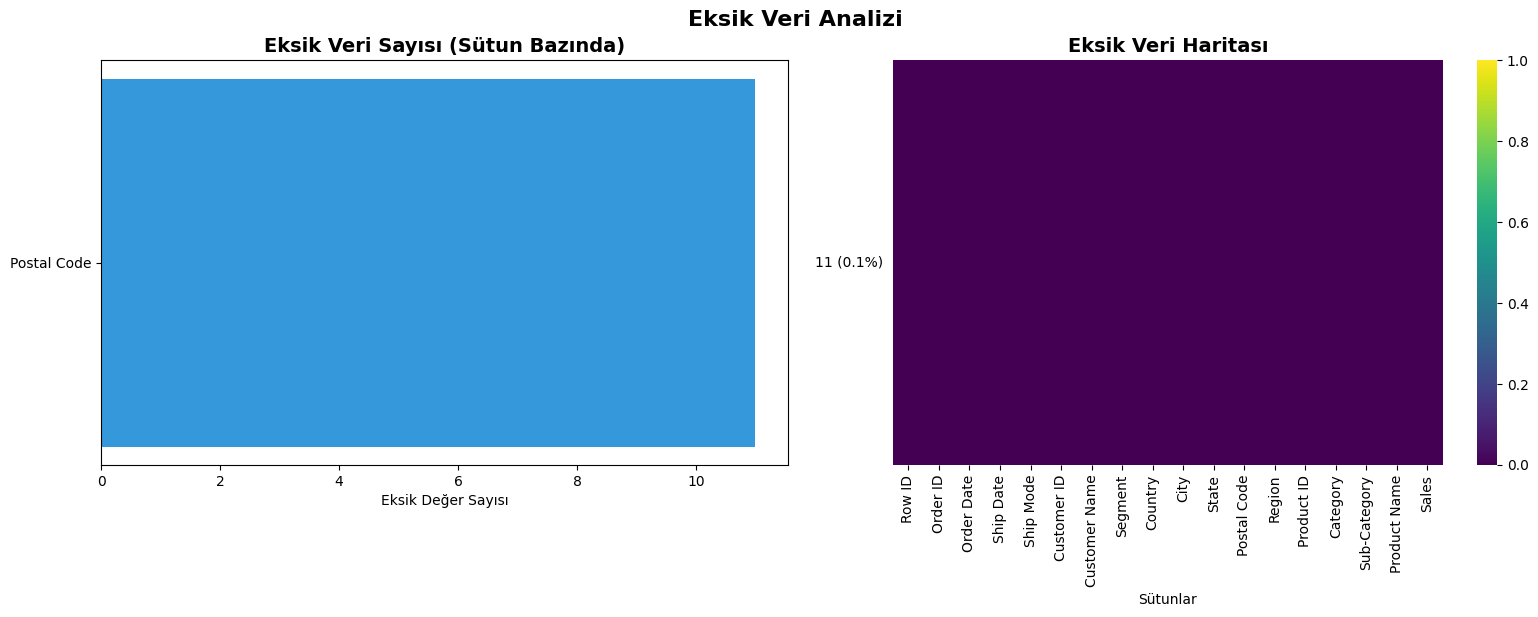

In [19]:
# Eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
eksik_olan = df.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
          for x in (eksik_olan / len(df) * 100)]

axes[0].barh(eksik_olan.index, eksik_olan.values, color=colors)
axes[0].set_title('Eksik Veri Sayısı (Sütun Bazında)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eksik Değer Sayısı')
for i, (val, col) in enumerate(zip(eksik_olan.values, eksik_olan.index)):
    axes[0].text(val + 1, i, f'{val} ({val/len(df)*100:.1f}%)', va='center')

# Heatmap
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Eksik Veri Haritası', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sütunlar')

plt.tight_layout()
plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [20]:
#aykırı değer fazla olduğunda kullanılır
#bos degerleri ortalamasi ile kapatir
df_temiz= df.copy()

yas_medyan =df_temiz['Postal Code'].median()

df_temiz['Postal Code'].fillna(yas_medyan, inplace=True)

df_temiz.isnull().sum()

/tmp/ipykernel_11266/334168229.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_temiz['Postal Code'].fillna(yas_medyan, inplace=True)


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
#Mod ise en çok görülen değerle doldurur
embarkeds=df_temiz['embarked'].mode()[0]
df_temiz['embarked'].fillna(embarkeds, inplace=True)
df_temiz.isnull().sum()

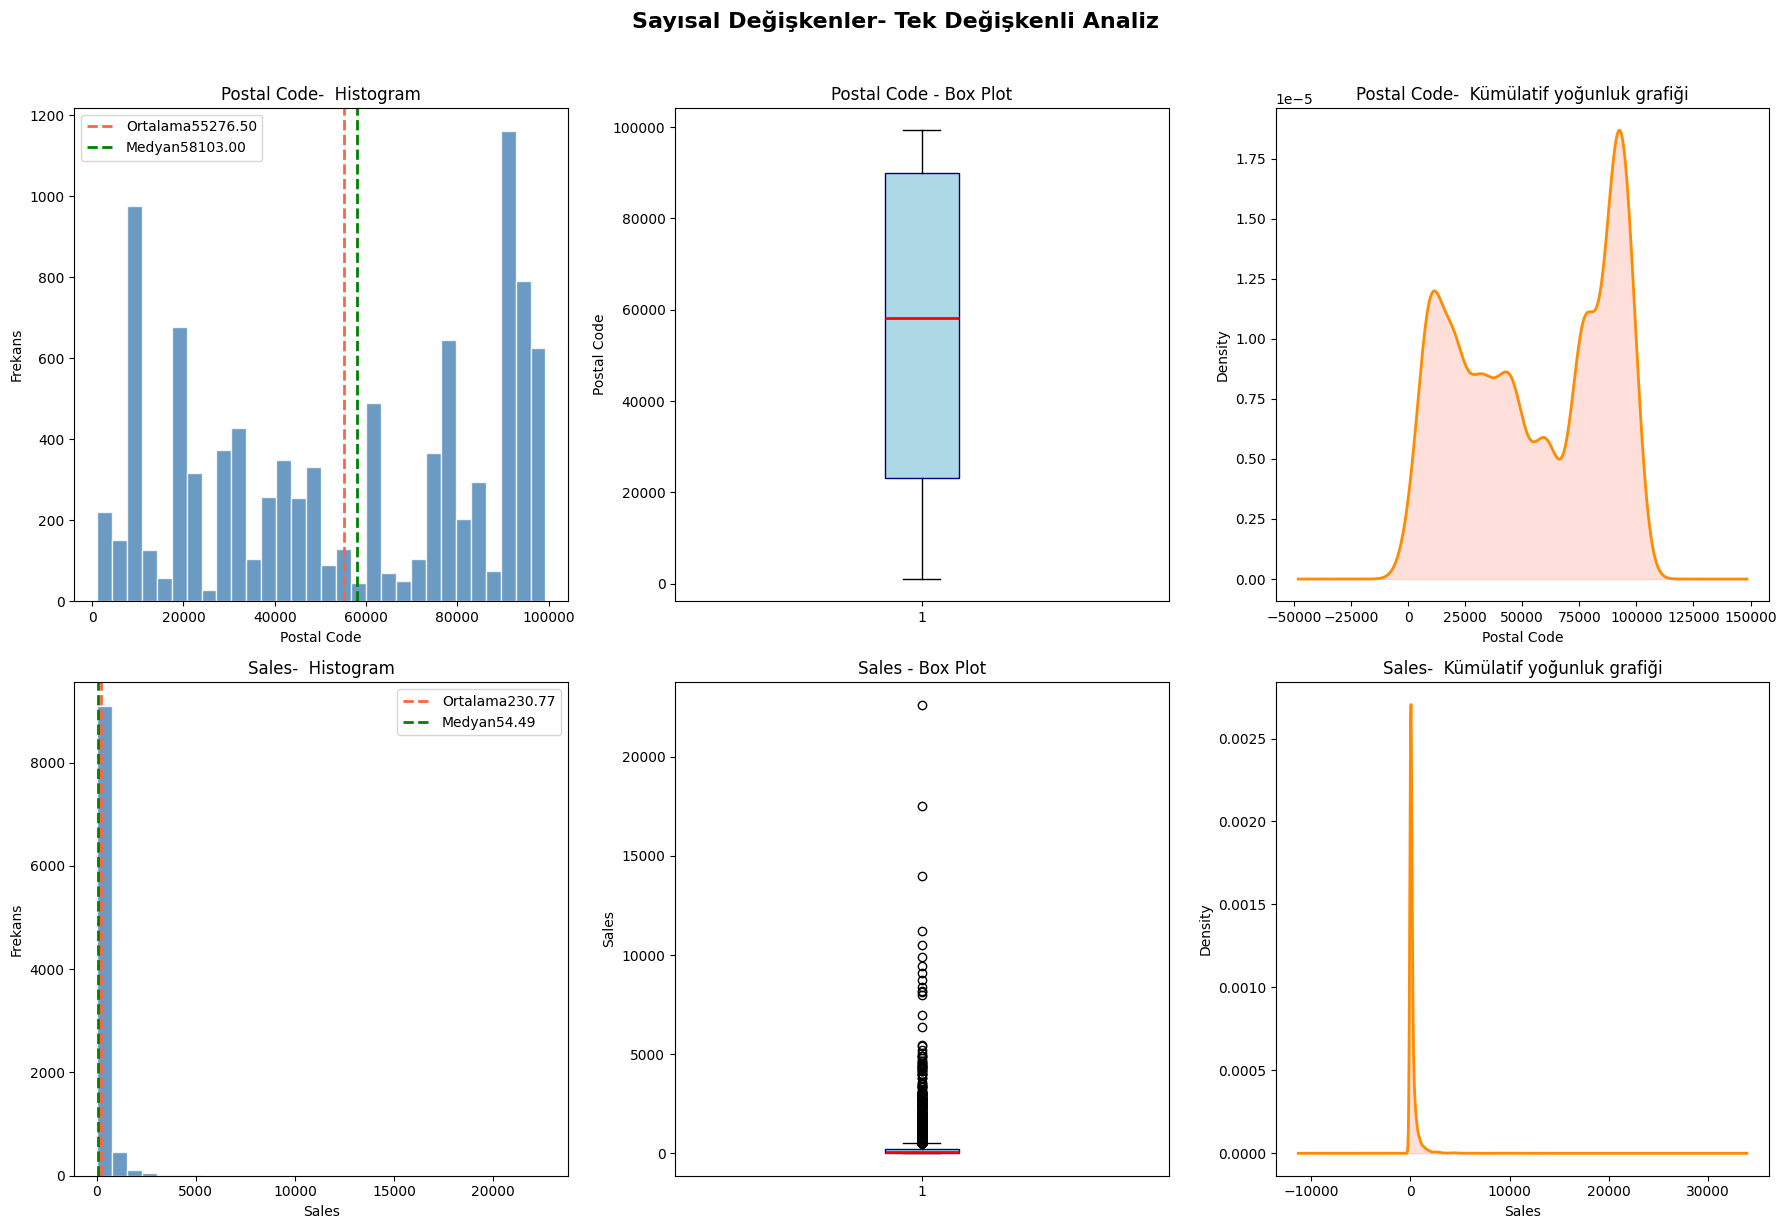

In [21]:
# sayısal değişkenler

sayisal_kolonlar =['Postal Code', 'Sales']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3 , figsize=(18, 6*len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
  veri = df_temiz[kolon].dropna()

  axes[i,0].hist(veri, bins=30, color="steelblue",edgecolor='white',alpha=0.8)
  axes[i,0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama{veri.mean():.2f}')
  axes[i,0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan{veri.median():.2f}')
  axes[i,0].set_title(f'{kolon}-  Histogram')
  axes[i,0].legend()
  axes[i,0].set_xlabel(kolon)
  axes[i,0].set_ylabel('Frekans')

      # Box plot
  axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
  axes[i, 1].set_title(f'{kolon} - Box Plot')
  axes[i, 1].set_ylabel(kolon)


  veri.plot.kde(ax=axes[i,2],color='darkorange',linewidth=2)
  axes[i,2].fill_between(axes[i,2].lines[0].get_xdata(),
                        axes[i,2].lines[0].get_ydata(),
                        color='tomato',alpha=0.2)
  axes[i,2].set_title(f'{kolon}-  Kümülatif yoğunluk grafiği')
  axes[i,2].set_xlabel(kolon)


plt.suptitle('Sayısal Değişkenler- Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
